# Imports and load the clean data

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the clean orders table we saved at the end of Notebook 1
orders_clean = pd.read_csv("../data/processed/orders_clean.csv", parse_dates=[
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
])

# Load the other tables we need for the funnel
orders   = pd.read_csv("../data/raw/olist_orders_dataset.csv")
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
reviews  = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")

print(f"Clean orders: {len(orders_clean):,}")
print(f"All orders:   {len(orders):,}")

Clean orders: 96,470
All orders:   99,441


# Fix date columns in the raw orders table

In [4]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print("Dates converted ✓")

Dates converted ✓


# Build the funnel stages

In [5]:
funnel = {
    "1. Order placed":    len(orders),
    "2. Order approved":  orders["order_approved_at"].notna().sum(),
    "3. Shipped":         orders["order_delivered_carrier_date"].notna().sum(),
    "4. Delivered":       (orders["order_status"] == "delivered").sum(),
    "5. Review left":     reviews["review_score"].notna().sum(),
}

print("=== PURCHASE FUNNEL ===\n")
for stage, count in funnel.items():
    print(f"  {stage}: {count:,}")

=== PURCHASE FUNNEL ===

  1. Order placed: 99,441
  2. Order approved: 99,281
  3. Shipped: 97,658
  4. Delivered: 96,478
  5. Review left: 99,224


# Calculate conversion rates between stages

In [6]:
print("=== CONVERSION RATES BETWEEN STAGES ===\n")

stages = list(funnel.values())
labels = list(funnel.keys())

for i in range(1, len(stages)):
    conversion = stages[i] / stages[i - 1] * 100
    drop        = stages[i - 1] - stages[i]
    print(f"  {labels[i-1]} → {labels[i]}")
    print(f"    Conversion: {conversion:.1f}%  |  Lost: {drop:,} orders\n")

=== CONVERSION RATES BETWEEN STAGES ===

  1. Order placed → 2. Order approved
    Conversion: 99.8%  |  Lost: 160 orders

  2. Order approved → 3. Shipped
    Conversion: 98.4%  |  Lost: 1,623 orders

  3. Shipped → 4. Delivered
    Conversion: 98.8%  |  Lost: 1,180 orders

  4. Delivered → 5. Review left
    Conversion: 102.8%  |  Lost: -2,746 orders



# Funnel chart

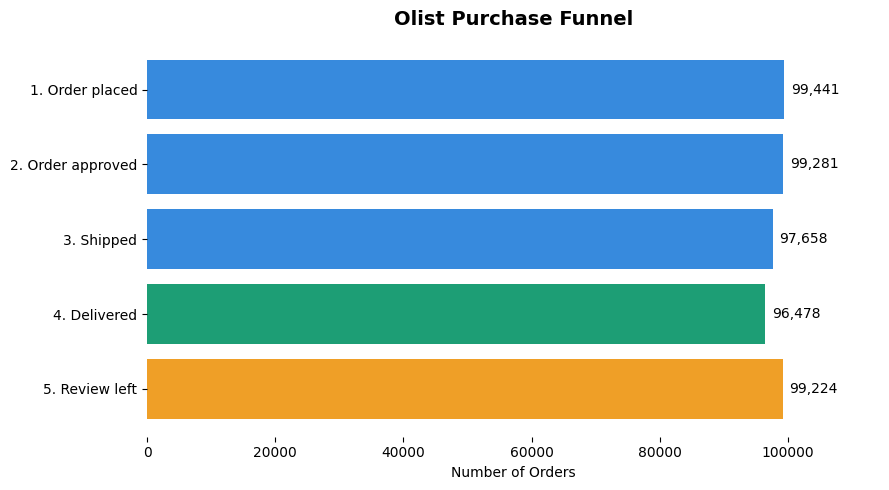

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

stages_list = list(funnel.keys())
counts_list = list(funnel.values())
colors      = ["#378ADD", "#378ADD", "#378ADD", "#1D9E75", "#EF9F27"]

bars = ax.barh(stages_list[::-1], counts_list[::-1], color=colors[::-1])

# Add value labels on each bar
for bar, val in zip(bars, counts_list[::-1]):
    ax.text(
        val + max(counts_list) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}",
        va="center",
        fontsize=10
    )

ax.set_xlabel("Number of Orders")
ax.set_title("Olist Purchase Funnel", fontsize=14, fontweight="bold", pad=12)
ax.set_xlim(0, max(counts_list) * 1.15)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig("../reports/02_funnel_chart.png", dpi=150)
plt.show()

# Revenue by month on delivered orders

In [8]:
# Join orders_clean with payments to get revenue
order_revenue = (
    payments.groupby("order_id")["payment_value"]
    .sum()
    .reset_index()
    .rename(columns={"payment_value": "revenue"})
)

orders_revenue = orders_clean.merge(order_revenue, on="order_id", how="left")

# Group by month
orders_revenue["month"] = orders_revenue["order_purchase_timestamp"].dt.to_period("M")
monthly_revenue = (
    orders_revenue.groupby("month")
    .agg(
        orders=("order_id", "count"),
        revenue=("revenue", "sum"),
        avg_order_value=("revenue", "mean")
    )
    .reset_index()
)

print(monthly_revenue.to_string(index=False))

  month  orders    revenue  avg_order_value
2016-09       1       0.00              NaN
2016-10     265   46566.71       175.723434
2016-12       1      19.62        19.620000
2017-01     750  127545.67       170.060893
2017-02    1653  271298.65       164.125015
2017-03    2546  414369.39       162.753099
2017-04    2303  390952.18       169.757785
2017-05    3545  566872.73       159.907681
2017-06    3135  490225.60       156.371802
2017-07    3872  566403.93       146.282007
2017-08    4193  646000.61       154.066446
2017-09    4150  701169.99       168.956624
2017-10    4478  751140.27       167.740123
2017-11    7288 1153393.22       158.259223
2017-12    5513  843199.17       152.947428
2018-01    7069 1078606.86       152.582665
2018-02    6555  966510.88       147.446359
2018-03    7003 1120678.00       160.028274
2018-04    6798 1132933.95       166.656951
2018-05    6749 1128836.69       167.259844
2018-06    6096 1011561.35       165.938542
2018-07    6156 1027383.10      

# Revenue over time chart

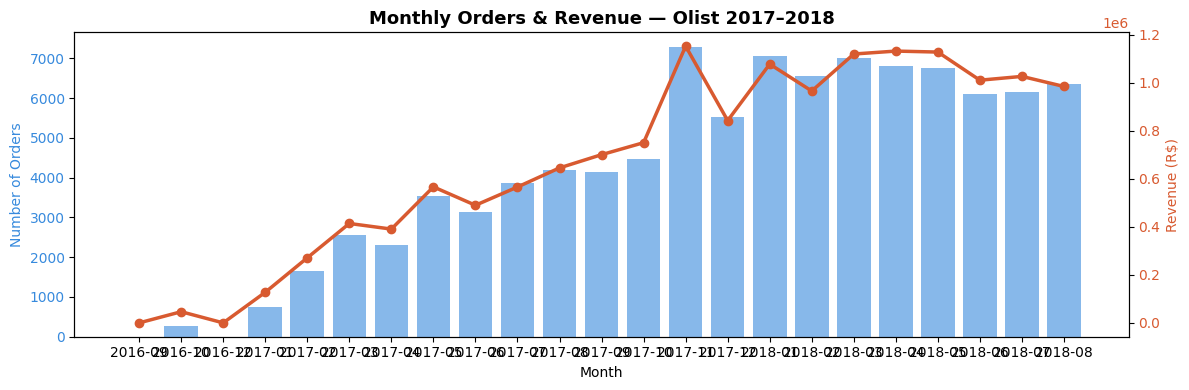

In [9]:
fig, ax1 = plt.subplots(figsize=(12, 4))

# Bar chart for order count
ax1.bar(
    monthly_revenue["month"].astype(str),
    monthly_revenue["orders"],
    color="#378ADD",
    alpha=0.6,
    label="Orders"
)
ax1.set_ylabel("Number of Orders", color="#378ADD")
ax1.tick_params(axis="y", labelcolor="#378ADD")

# Line chart for revenue on second axis
ax2 = ax1.twinx()
ax2.plot(
    monthly_revenue["month"].astype(str),
    monthly_revenue["revenue"],
    color="#D85A30",
    linewidth=2.5,
    marker="o",
    label="Revenue"
)
ax2.set_ylabel("Revenue (R$)", color="#D85A30")
ax2.tick_params(axis="y", labelcolor="#D85A30")

ax1.set_title("Monthly Orders & Revenue — Olist 2017–2018", fontsize=13, fontweight="bold")
ax1.set_xlabel("Month")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../reports/02_monthly_revenue.png", dpi=150)
plt.show()

# Average order value over time

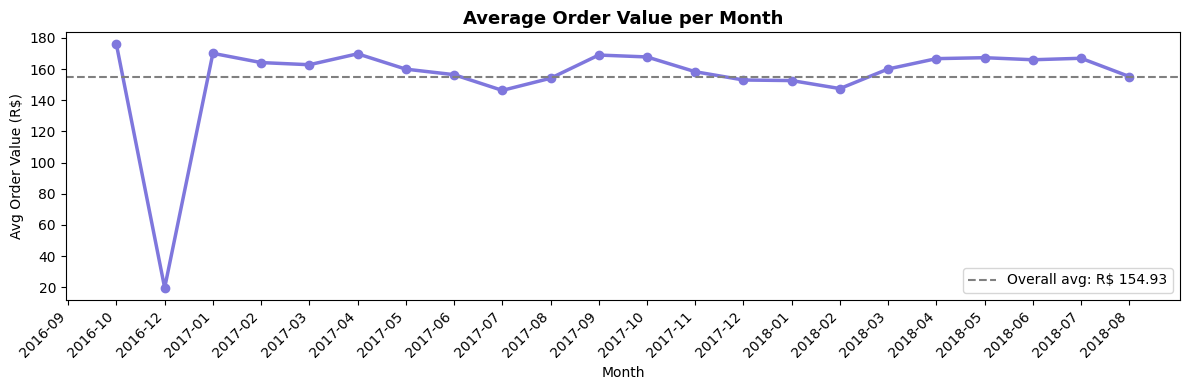

In [10]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    monthly_revenue["month"].astype(str),
    monthly_revenue["avg_order_value"],
    color="#7F77DD",
    linewidth=2.5,
    marker="o"
)
ax.axhline(
    monthly_revenue["avg_order_value"].mean(),
    color="gray",
    linestyle="--",
    label=f"Overall avg: R$ {monthly_revenue['avg_order_value'].mean():.2f}"
)
ax.set_title("Average Order Value per Month", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Avg Order Value (R$)")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../reports/02_avg_order_value.png", dpi=150)
plt.show()

# Save the enriched orders table

In [11]:
orders_revenue.to_csv("../data/processed/orders_revenue.csv", index=False)

print(f"Saved orders_revenue with {len(orders_revenue):,} rows")
print(f"Columns: {orders_revenue.columns.tolist()}")
print(f"\nTotal revenue in dataset: R$ {orders_revenue['revenue'].sum():,.2f}")
print(f"Average order value:      R$ {orders_revenue['revenue'].mean():.2f}")
print(f"Median order value:       R$ {orders_revenue['revenue'].median():.2f}")

Saved orders_revenue with 96,470 rows
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'month', 'revenue']

Total revenue in dataset: R$ 15,421,082.85
Average order value:      R$ 159.86
Median order value:       R$ 105.28
